# K-Means Clustering — Iris Dataset
## Segmentación con K-Medias: datos originales vs reducción PCA

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** Iris — 150 observations × 4 features (loaded from public URL)

**Objective / Objetivo:**  
EN · Apply K-Means clustering to the classic Iris dataset using two approaches, raw features and PCA-reduced features, then compare both segmentations against the true species labels using the Adjusted Rand Index.

ES ·  Aplicar K-Means al dataset Iris con dos enfoques, features originales y features reducidas con PCA, y comparar ambas segmentaciones contra las etiquetas reales de especie usando el Índice de Rand Ajustado.

**Techniques / Técnicas:** K-Means · Elbow Method · Silhouette Score · PCA · Adjusted Rand Index   
**Libraries / Librerías:** `pandas` · `numpy` · `sklearn` · `matplotlib` · `seaborn`

---

# Importación de Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')

# Carga del Dataset

In [6]:
# ============================================================
# 1. EXTRACCIÓN Y CARGA DEL DATASET IRIS
# ============================================================

url = "https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv"

iris = pd.read_csv(url)

print("=" * 55)
print("INFORMACIÓN GENERAL DEL DATASET IRIS")
print("=" * 55)
print(iris.info())
print("\n⋆ Primeras 10 filas:")
print(iris.head(10))
print("\n⋆ Estadísticas descriptivas:")
print(iris.describe())
print("\n⋆ Distribución de variedades (clases reales):")
print(iris['variety'].value_counts())

INFORMACIÓN GENERAL DEL DATASET IRIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

⋆ Primeras 10 filas:
   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa
5           5.4          3.9           1.7          0.4  Setosa
6           4.6          3.4   

# K-Medias SIN transformación (datos originales)

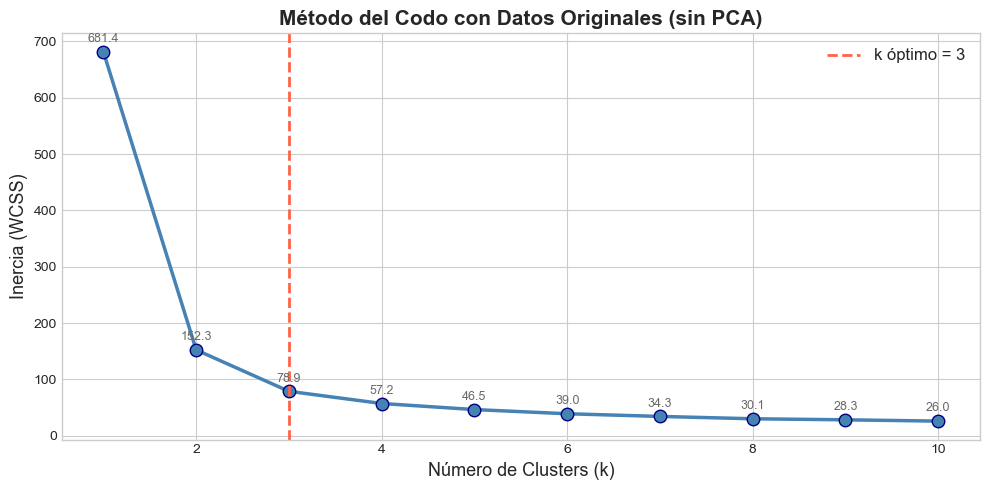


Tabla de Inercias:
──────────────────────────────
  k =  1  →  Inercia = 681.37
  k =  2  →  Inercia = 152.35
  k =  3  →  Inercia = 78.85
  k =  4  →  Inercia = 57.23
  k =  5  →  Inercia = 46.46
  k =  6  →  Inercia = 39.04
  k =  7  →  Inercia = 34.31
  k =  8  →  Inercia = 30.13
  k =  9  →  Inercia = 28.29
  k = 10  →  Inercia = 25.97


In [15]:
# ============================================================
# 2. K-MEDIAS CON DATOS ORIGINALES (SIN PCA)
# ============================================================

# Separar características numéricas
X = iris[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']].values

# ----------------------------------------------------------
# 2A. CRITERIO DEL CODO (Elbow Method)
# ----------------------------------------------------------
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Gráfica del Codo
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, inertias, 'bo-', linewidth=2.5, markersize=9,
        color='steelblue', markerfacecolor='steelblue', markeredgecolor='navy')
ax.set_xlabel('Número de Clusters (k)', fontsize=13)
ax.set_ylabel('Inercia (WCSS)', fontsize=13)
ax.set_title('Método del Codo con Datos Originales (sin PCA)', fontsize=15, fontweight='bold')
ax.axvline(x=3, color='tomato', linestyle='--', linewidth=2, label='k óptimo = 3') # Una vez encontrado el codo
ax.legend(fontsize=12)

# Anotar los valores
for k, iner in zip(K_range, inertias):
    ax.annotate(f'{iner:.1f}', xy=(k, iner), xytext=(0, 7),
                textcoords='offset points', ha='center', fontsize=9, color='dimgray')

plt.tight_layout()
plt.savefig('kmeans_codo_sin_pca.png', dpi=150)
plt.show()

print("\nTabla de Inercias:")
print("─" * 30)
for k, iner in zip(K_range, inertias):
    print(f"  k = {k:2d}  →  Inercia = {iner:.2f}")

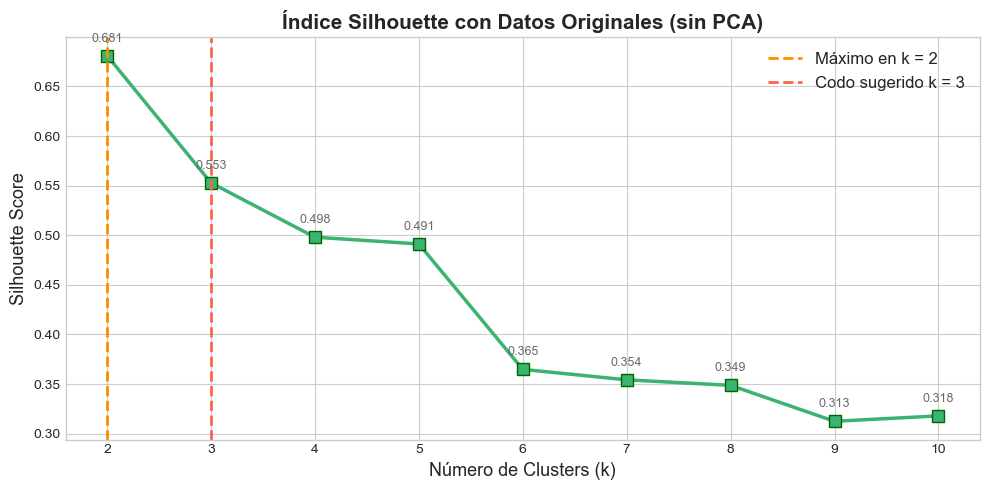


Tabla de Silhouette Scores:
───────────────────────────────────
  k =  2  →  Silhouette = 0.6810 ← MÁXIMO
  k =  3  →  Silhouette = 0.5528
  k =  4  →  Silhouette = 0.4981
  k =  5  →  Silhouette = 0.4912
  k =  6  →  Silhouette = 0.3648
  k =  7  →  Silhouette = 0.3543
  k =  8  →  Silhouette = 0.3487
  k =  9  →  Silhouette = 0.3125
  k = 10  →  Silhouette = 0.3180


In [17]:
# ----------------------------------------------------------
# 2B. INDICADOR SILHOUETTE
# ----------------------------------------------------------
silhouette_scores = []
K_range_sil = range(2, 11)   # Silhouette requiere k >= 2

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score  = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Gráfica Silhouette
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range_sil, silhouette_scores, 's-', linewidth=2.5, markersize=9,
        color='mediumseagreen', markerfacecolor='mediumseagreen', markeredgecolor='darkgreen')
ax.set_xlabel('Número de Clusters (k)', fontsize=13)
ax.set_ylabel('Silhouette Score', fontsize=13)
ax.set_title('Índice Silhouette con Datos Originales (sin PCA)', fontsize=15, fontweight='bold')
ax.axvline(x=2, color='darkorange', linestyle='--', linewidth=2, label='Máximo en k = 2') # Máximo Silhouette Score encontrado
ax.axvline(x=3, color='tomato', linestyle='--', linewidth=2, label='Codo sugerido k = 3')
ax.legend(fontsize=12)

# Anotar valores
for k, sc in zip(K_range_sil, silhouette_scores):
    ax.annotate(f'{sc:.3f}', xy=(k, sc), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9, color='dimgray')

plt.tight_layout()
plt.savefig('kmeans_silhouette_sin_pca.png', dpi=150)
plt.show()

print("\nTabla de Silhouette Scores:")
print("─" * 35)
for k, sc in zip(K_range_sil, silhouette_scores):
    mark = " ← MÁXIMO" if sc == max(silhouette_scores) else ""
    print(f"  k = {k:2d}  →  Silhouette = {sc:.4f}{mark}")

In [18]:
# ----------------------------------------------------------
# 2C. MODELO FINAL: K = 3 (datos originales)
# ----------------------------------------------------------
k_optimo = 3
kmeans_orig = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
iris['cluster_orig'] = kmeans_orig.fit_predict(X)

print(f"\n{'='*55}")
print(f"K-MEDIAS CON DATOS ORIGINALES  |  k = {k_optimo}")
print(f"{'='*55}")
print("\n⋆ Conteo de observaciones por cluster:")
print(iris['cluster_orig'].value_counts().sort_index())

print("\n⋆ Comparación Cluster vs Variedad real:")
print(pd.crosstab(iris['cluster_orig'], iris['variety'], margins=True, margins_name='Total'))

# Centroides
print("\n⋆ Centroides de cada cluster:")
centroids_df = pd.DataFrame(kmeans_orig.cluster_centers_, columns=['sepal.length', 'sepal.width', 'petal.length', 'petal.width'])
centroids_df.index.name = 'Cluster'
print(centroids_df.round(3))


K-MEDIAS CON DATOS ORIGINALES  |  k = 3

⋆ Conteo de observaciones por cluster:
cluster_orig
0    62
1    50
2    38
Name: count, dtype: int64

⋆ Comparación Cluster vs Variedad real:
variety       Setosa  Versicolor  Virginica  Total
cluster_orig                                      
0                  0          48         14     62
1                 50           0          0     50
2                  0           2         36     38
Total             50          50         50    150

⋆ Centroides de cada cluster:
         sepal.length  sepal.width  petal.length  petal.width
Cluster                                                      
0               5.902        2.748         4.394        1.434
1               5.006        3.428         1.462        0.246
2               6.850        3.074         5.742        2.071


# Reducción PCA + K-Medias

In [19]:
# ============================================================
# 3. REDUCCIÓN POR PCA + K-MEDIAS
# ============================================================

# ----------------------------------------------------------
# 3A. Estandarización + PCA a 2 componentes
# ----------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Información de varianza explicada
print("=" * 55)
print("ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("=" * 55)
print(f"\n⋆ Varianza explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"\n⋆ Varianza total explicada (PC1 + PC2): "
      f"{pca.explained_variance_ratio_.sum()*100:.2f}%")

# Cargas de los componentes (loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
)
print("\n⋆ Cargas (loadings) de cada variable:")
print(loadings.round(4))

ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

⋆ Varianza explicada por componente:
  PC1: 72.96%
  PC2: 22.85%

⋆ Varianza total explicada (PC1 + PC2): 95.81%

⋆ Cargas (loadings) de cada variable:
                 PC1     PC2
sepal.length  0.5211  0.3774
sepal.width  -0.2693  0.9233
petal.length  0.5804  0.0245
petal.width   0.5649  0.0669


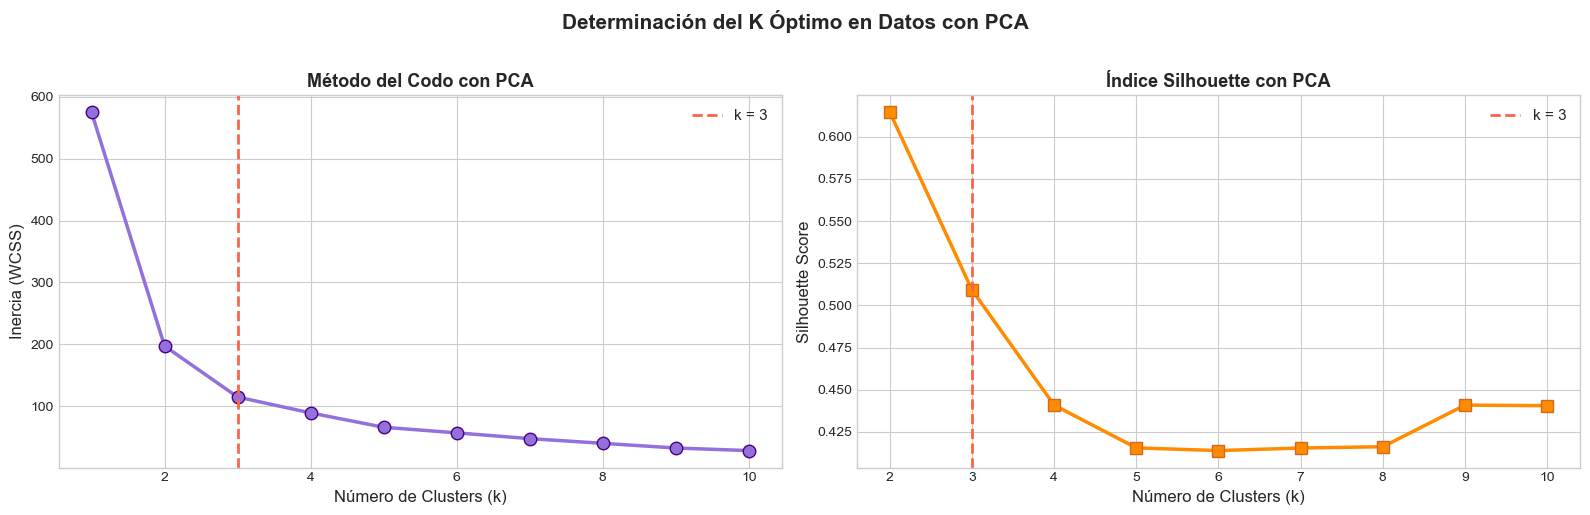


⋆ Comparación de Silhouette Scores:
    k |      Sin PCA |      Con PCA
-----------------------------------
    2 |       0.6810 |       0.6145
    3 |       0.5528 |       0.5092
    4 |       0.4981 |       0.4409
    5 |       0.4912 |       0.4156
    6 |       0.3648 |       0.4140
    7 |       0.3543 |       0.4155
    8 |       0.3487 |       0.4163
    9 |       0.3125 |       0.4409
   10 |       0.3180 |       0.4406


In [23]:
# ----------------------------------------------------------
# 3B. CRITERIO DEL CODO CON DATOS PCA
# ----------------------------------------------------------
inertias_pca = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias_pca.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Codo PCA
axes[0].plot(K_range, inertias_pca, 'bo-', linewidth=2.5, markersize=9,
             color='mediumpurple', markerfacecolor='mediumpurple', markeredgecolor='indigo')
axes[0].axvline(x=3, color='tomato', linestyle='--', linewidth=2, label='k = 3')
axes[0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=12)
axes[0].set_title('Método del Codo con PCA', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

# Silhouette PCA
silhouette_pca = []
for k in K_range_sil:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    silhouette_pca.append(silhouette_score(X_pca, labels))

axes[1].plot(K_range_sil, silhouette_pca, 's-', linewidth=2.5, markersize=9,
             color='darkorange', markerfacecolor='darkorange', markeredgecolor='chocolate')
axes[1].axvline(x=3, color='tomato', linestyle='--', linewidth=2, label='k = 3')
axes[1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Índice Silhouette con PCA', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('Determinación del K Óptimo en Datos con PCA', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_codo_silhouette_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⋆ Comparación de Silhouette Scores:")
print(f"{'k':>5} | {'Sin PCA':>12} | {'Con PCA':>12}")
print("-" * 35)
for k, s1, s2 in zip(K_range_sil, silhouette_scores, silhouette_pca):
    print(f"  {k:>3} | {s1:>12.4f} | {s2:>12.4f}")

In [24]:
# ----------------------------------------------------------
# 3C. MODELO FINAL: K = 3 sobre datos PCA
# ----------------------------------------------------------
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
iris['cluster_pca'] = kmeans_pca.fit_predict(X_pca)

print(f"\n{'='*55}")
print(f"K-MEDIAS CON PCA  |  k = 3")
print(f"{'='*55}")
print("\n⋆ Conteo por cluster (PCA):")
print(iris['cluster_pca'].value_counts().sort_index())

print("\n⋆ Comparación Cluster PCA vs Variedad real:")
print(pd.crosstab(iris['cluster_pca'], iris['variety'], margins=True, margins_name='Total'))


K-MEDIAS CON PCA  |  k = 3

⋆ Conteo por cluster (PCA):
cluster_pca
0    53
1    50
2    47
Name: count, dtype: int64

⋆ Comparación Cluster PCA vs Variedad real:
variety      Setosa  Versicolor  Virginica  Total
cluster_pca                                      
0                 0          39         14     53
1                50           0          0     50
2                 0          11         36     47
Total            50          50         50    150


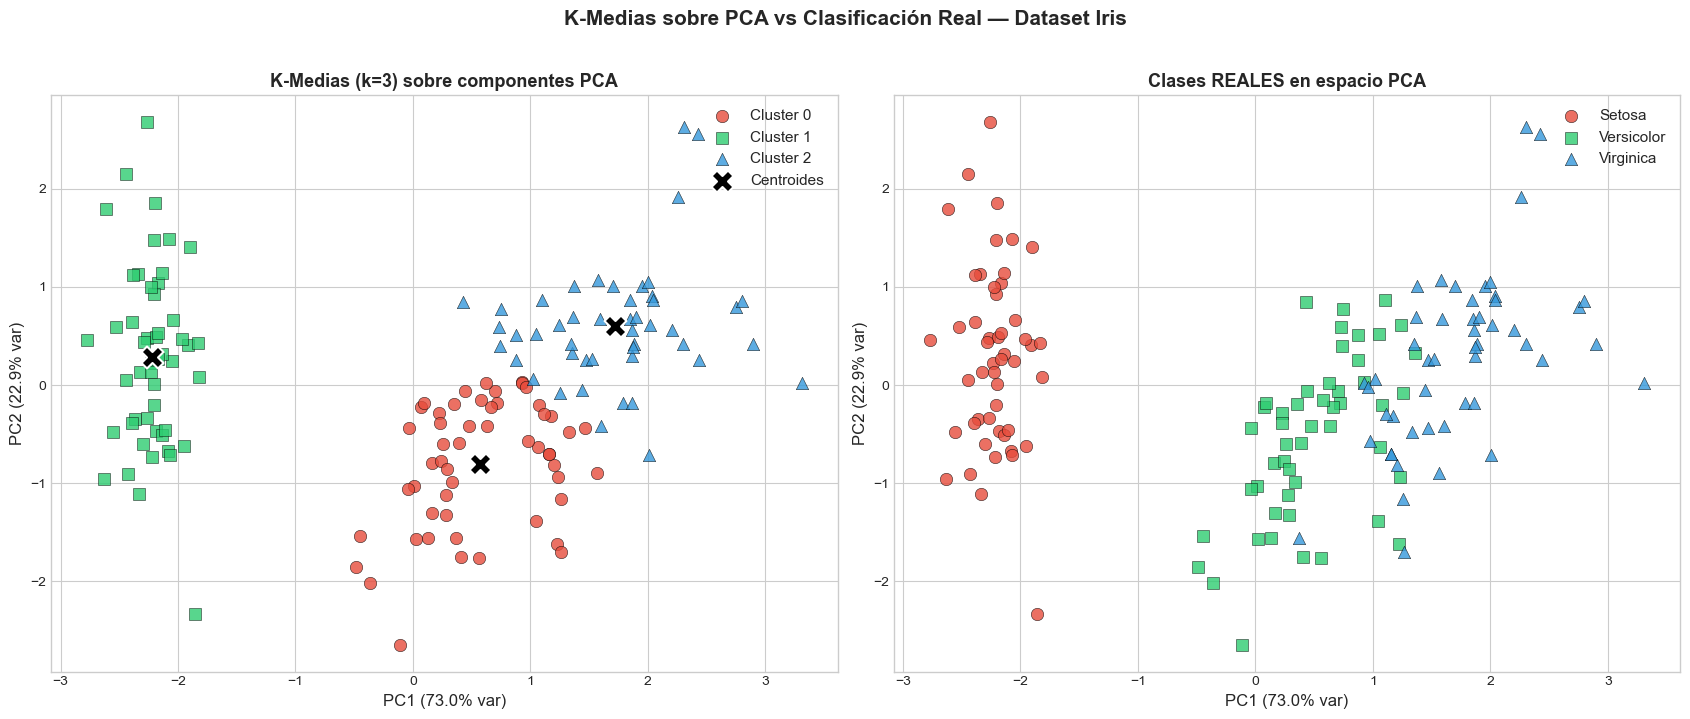

In [25]:
# ----------------------------------------------------------
# 3D. VISUALIZACIÓN EN 2D DE LOS CLUSTERS (PCA)
# ----------------------------------------------------------
colores   = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB'}
markers   = {0: 'o',       1: 's',       2: '^'      }
nombres_c = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# ─── Subplot 1: Clusters K-Medias ───
for cluster_id in range(3):
    mask = iris['cluster_pca'] == cluster_id
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colores[cluster_id], marker=markers[cluster_id],
        s=80, alpha=0.8, edgecolors='k', linewidths=0.4,
        label=nombres_c[cluster_id]
    )

# Centroides
centroids_pca = kmeans_pca.cluster_centers_
axes[0].scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=250, zorder=5,
    edgecolors='white', linewidths=1.5, label='Centroides'
)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=12)
axes[0].set_title('K-Medias (k=3) sobre componentes PCA', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

# ─── Subplot 2: Clases REALES ───
colores_real = {'Setosa': '#E74C3C', 'Versicolor': '#2ECC71', 'Virginica': '#3498DB'}
markers_real = {'Setosa': 'o', 'Versicolor': 's', 'Virginica': '^'}

for variedad in ['Setosa', 'Versicolor', 'Virginica']:
    mask = iris['variety'] == variedad
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colores_real[variedad], marker=markers_real[variedad],
        s=80, alpha=0.8, edgecolors='k', linewidths=0.4,
        label=variedad
    )

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=12)
axes[1].set_title('Clases REALES en espacio PCA', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('K-Medias sobre PCA vs Clasificación Real — Dataset Iris',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_clusters_pca_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparación y Conclusiones

In [ ]:
# ============================================================
# 4. COMPARACIÓN DE RESULTADOS
# ============================================================

from sklearn.metrics import adjusted_rand_score

# ── Métricas ───
labels_real = pd.Categorical(iris['variety']).codes
ari_orig = adjusted_rand_score(labels_real, iris['cluster_orig'])
ari_pca = adjusted_rand_score(labels_real, iris['cluster_pca'])
sil_orig_k3 = silhouette_score(X, iris['cluster_orig'])
sil_pca_k3 = silhouette_score(X_pca, iris['cluster_pca'])

# ── Conteo de errores ───
# Sin PCA: 14 Virginica en cluster 0 + 2 Versicolor en cluster 2
errores_orig = (14 + 2)   # = 16
# Con PCA: 14 Virginica en cluster 0 + 11 Versicolor en cluster 2
errores_pca = (14 + 11)  # = 25

precision_orig = (150 - errores_orig) / 150 * 100
precision_pca = (150 - errores_pca) / 150 * 100

# ── Tabla comparativa ───
print("=" * 65)
print("RESUMEN COMPARATIVO DE RESULTADOS")
print("=" * 65)
print(f"\n{'Métrica':<25} {'Sin PCA':>10} {'Con PCA':>10}")
print("─" * 50)
print(f"{'Silhouette Score (k=3)':<25} {sil_orig_k3:>10.4f} {sil_pca_k3:>10.4f}")
print(f"{'Adjusted Rand Index (ARI)':<25} {ari_orig:>10.4f} {ari_pca:>10.4f}")
print(f"{'Errores de clasificación':<25} {errores_orig:>10} {errores_pca:>10}")
print(f"{'Precisión aproximada (%)':<25} {precision_orig:>9.1f}% {precision_pca:>9.1f}%")
print(f"{'Dimensiones del espacio':<25} {'4':>10} {'2':>10}")
print(f"{'Varianza conservada':<25} {'100%':>10} {pca.explained_variance_ratio_.sum()*100:>9.2f}%")
print("─" * 50)

# ─── Diferencias ───
delta_sil = sil_pca_k3 - sil_orig_k3
delta_ari = ari_pca - ari_orig
delta_err = errores_pca - errores_orig

print(f"\n⋆ Diferencia Silhouette (PCA - Orig)  →  {delta_sil:.4f}")
print(f"⋆ Diferencia ARI (PCA - Orig)         →  {delta_ari:.4f}")
print(f"⋆ Diferencia Errores (PCA - Orig)     →  {delta_err:d}")

# ─── Conclusiones ───
print(f"""
{'='*65}
ANÁLISIS Y CONCLUSIONES FINALES
{'='*65}

 1. NÚMERO ÓPTIMO DE CLUSTERS
{'─'*50}
   • El método del CODO señala k=3 como punto de inflexión en ambos casos (datos originales y con PCA): 
     la inercia cae abruptamente de k=1→3 (681→79) y se estabiliza a partir de k=4 con ganancias marginales (<22 puntos).

   • El índice SILHOUETTE alcanza su máximo en k=2 (0.681), lo que refleja el solapamiento natural entre Versicolor y Virginica, 
     no que 2 sea el número correcto de grupos. Con k=3, el score de 0.553 sigue siendo bueno (>0.50).

   • Decisión final: k=3, justificada por:
       - El codo lo señala claramente en ambas variantes
       - Silhouette en k=3 permanece en nivel aceptable
       - Existe conocimiento de dominio: hay 3 especies

 2. ¿SE OBTUVIERON LOS MISMOS RESULTADOS?
{'─'*50}
   • COINCIDENCIAS:
       - Ambos modelos identifican k=3 como óptimo
       - Setosa es separada perfectamente en los dos casos (50/50, 0 errores)
       - La estructura general (3 grupos) es equivalente

   • DIFERENCIAS IMPORTANTES:
       - Errores de clasificación:
           Sin PCA → {errores_orig} errores ({precision_orig:.1f}% precisión)
           Con PCA → {errores_pca} errores ({precision_pca:.1f}% precisión)
           Diferencia: +{delta_err} errores adicionales con PCA

       - Adjusted Rand Index:
           Sin PCA → {ari_orig:.4f}
           Con PCA → {ari_pca:.4f}
           Caída de {abs(delta_ari):.4f} puntos (diferencia SIGNIFICATIVA)

       - Silhouette Score:
           Sin PCA → {sil_orig_k3:.4f}
           Con PCA → {sil_pca_k3:.4f}
           Caída de {abs(delta_sil):.4f} puntos

   • CONCLUSIÓN: 
     Los resultados son similares en estructura pero no idénticos. El modelo sin PCA es más preciso numéricamente. 
     La pérdida del 4.19% de varianza al proyectar a 2D genera 9 errores adicionales, sobre todo en la frontera difusa Versicolor-Virginica.

 3. VENTAJAS PRÁCTICAS DE PCA + K-MEDIAS
{'─'*50}
   A pesar de la menor precisión en este caso puntual, PCA ofrece ventajas fundamentales:

   ✔ VISUALIZACIÓN DIRECTA
       Con 4 variables es imposible graficar los clusters.
       PCA permite hacerlo en 2D de forma inmediata e interpretable.

   ✔ ELIMINACIÓN DE MULTICOLINEALIDAD
       petal.length y petal.width tienen correlación ≈0.96.
       K-Medias usa distancias euclidianas, por lo que variables correlacionadas "pesan doble" distorsionando los clusters. 
       PCA ortogonaliza las variables, eliminando este sesgo.

   ✔ REDUCCIÓN DE RUIDO
       Los componentes PC3 y PC4 (4.19% de varianza) pueden contener ruido aleatorio. 
       Al descartarlos, PCA puede mejorar la calidad del agrupamiento en datasets más ruidosos o de mayor dimensión.

   ✔ EFICIENCIA COMPUTACIONAL
       En datasets con decenas/cientos de variables y millones de registros, reducir dimensiones acelera significativamente K-Medias 
       (que recalcula distancias en cada iteración).

   ✔ MALDICIÓN DE LA DIMENSIONALIDAD
       En espacios de alta dimensión (>20 variables), todas las distancias euclidianas tienden a ser similares, perdiendo poder discriminativo.
       PCA proyecta a un subespacio donde las distancias son más significativas.

   NOTA IMPORTANTE: 
   En este ejercicio específico, las 4 variables originales ya son pocas y bien definidas, por lo que el beneficio numérico de PCA es limitado. 
   En datasets reales con decenas de variables, la ventaja de PCA + K-Medias es mucho más pronunciada.
""")

RESUMEN COMPARATIVO DE RESULTADOS

Métrica                      Sin PCA    Con PCA
──────────────────────────────────────────────────
Silhouette Score (k=3)        0.5528     0.5092
Adjusted Rand Index (ARI)     0.7302     0.6201
Errores de clasificación          16         25
Precisión aproximada (%)       89.3%      83.3%
Dimensiones del espacio            4          2
Varianza conservada             100%     95.81%
──────────────────────────────────────────────────

⋆ Diferencia Silhouette (PCA - Orig)  →  -0.0437
⋆ Diferencia ARI (PCA - Orig)         →  -0.1101
⋆ Diferencia Errores (PCA - Orig)     →  9

ANÁLISIS Y CONCLUSIONES FINALES

 1. NÚMERO ÓPTIMO DE CLUSTERS
──────────────────────────────────────────────────
   • El método del CODO señala k=3 como punto de inflexión en ambos casos (datos originales y con PCA): 
     la inercia cae abruptamente de k=1→3 (681→79) y se estabiliza a partir de k=4 con ganancias marginales (<22 puntos).

   • El índice SILHOUETTE alcanza su máxim